In [1]:
!pip install seabird

In [3]:
import os

folder = "/Users/ej/Desktop/Applied Ocean Observation Technologies/SEABIRD/Processed"

files = [f for f in os.listdir(folder) if f.endswith(".cnv")]
print("Files found:", files)

Files found: ['2026-bio-494.cnv', '2026-bio-497.cnv', '2026-bio-480-10.cnv', '2026-bio-508.cnv', '2026-bio-482-5.cnv', '2026-bio-496.cnv', '2026-bio-492.cnv', '2026-bio-486.cnv', '2026-bio-493.cnv', '2026-bio-478.cnv', '2026-bio-491.cnv', '2026-bio-490.cnv', '2026-bio-484.cnv', '2026-bio-485-1.cnv', '2026-bio-477-13.cnv', '2026-bio-481-9.cnv', '2026-bio-476.cnv', '2026-bio-489.cnv', '2026-bio-502.cnv', '2026-bio-488.cnv', '2026-bio-475.cnv', '2026-bio-500.cnv', '2026-bio-505.cnv', '2026-bio-498.cnv', '2026-bio-507.cnv', '2026-bio-506.cnv', '2026-bio-499.cnv']


In [4]:
from seabird.cnv import fCNV

profiles = []

for file in files:
    path = os.path.join(folder, file)
    profiles.append(fCNV(path))

print("Loaded", len(profiles), "profiles")

Loaded 27 profiles


In [5]:
print(profiles[0].keys())

['DEPTH', 'PSAL', 'tv290C', 'flag']


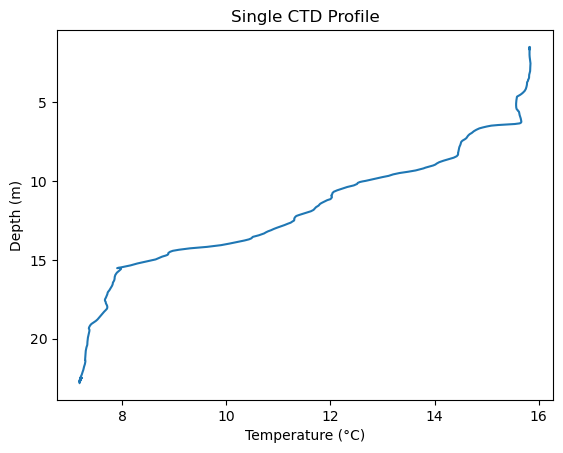

In [7]:
import matplotlib.pyplot as plt

p = profiles[0]

plt.plot(p['tv290C'], p['DEPTH'])
plt.gca().invert_yaxis()

plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title("Single CTD Profile")

plt.show()

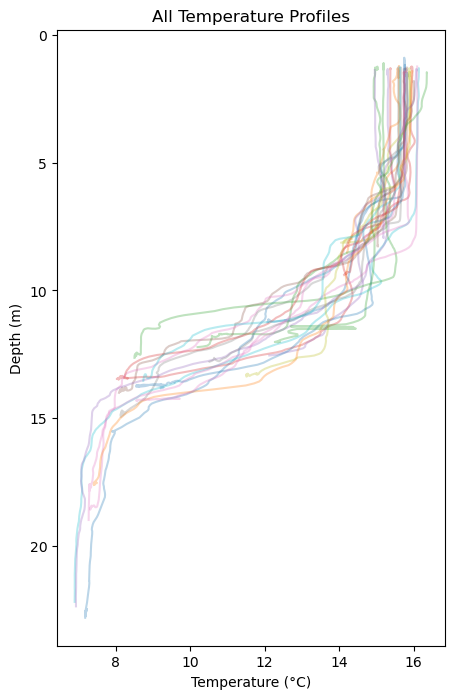

In [8]:
plt.figure(figsize=(5, 8))

for p in profiles:
    try:
        plt.plot(p['tv290C'], p['DEPTH'], alpha=0.3)
    except:
        continue

plt.gca().invert_yaxis()
plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title("All Temperature Profiles")

plt.show()

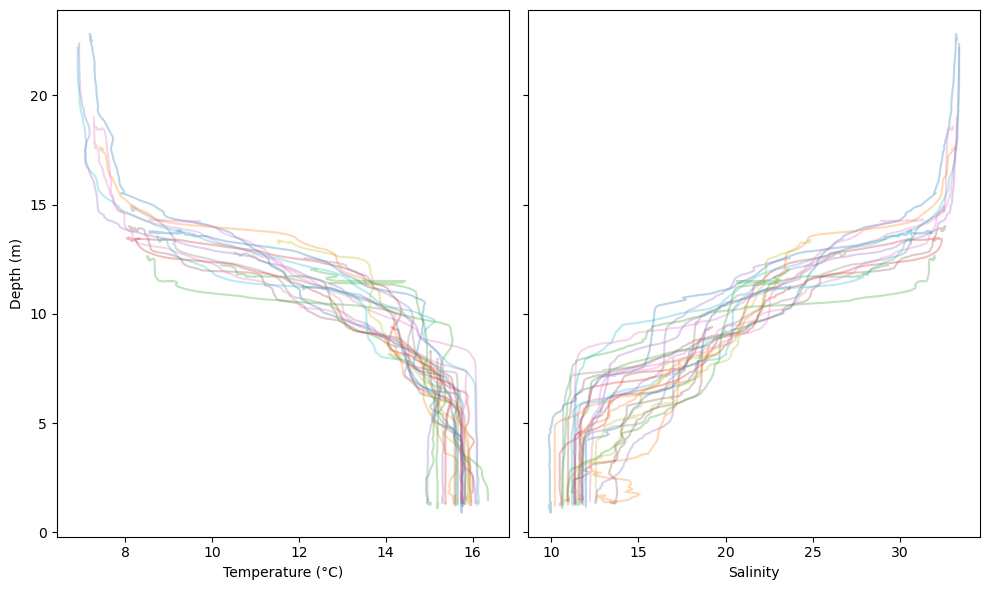

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

for p in profiles:
    axes[0].plot(p['tv290C'], p['DEPTH'], alpha=0.3)
    axes[1].plot(p['PSAL'], p['DEPTH'], alpha=0.3)

# formatting
for ax in axes:
    ax.invert_yaxis()

axes[0].set_xlabel("Temperature (°C)")
axes[1].set_xlabel("Salinity")
axes[0].set_ylabel("Depth (m)")

plt.tight_layout()
plt.show()

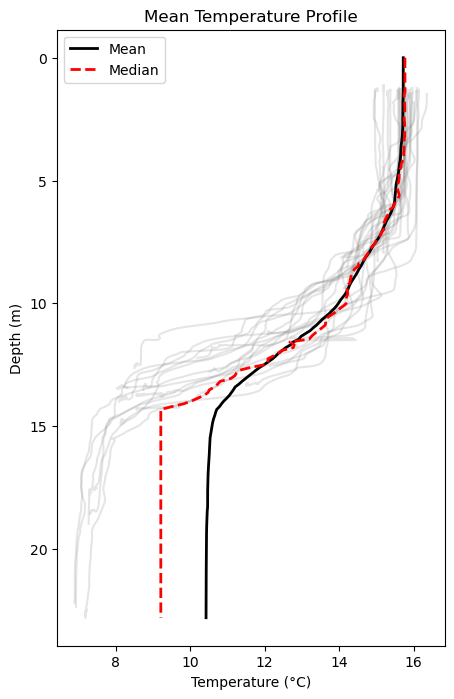

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define common depth grid
max_depth = max([np.nanmax(p['DEPTH']) for p in profiles])
common_depth = np.linspace(0, max_depth, 200)

interp_temps = []

# 2. Interpolate each profile onto common depth
for p in profiles:
    depth = p['DEPTH']
    temp = p['tv290C']
    
    mask = ~np.isnan(depth) & ~np.isnan(temp)
    
    try:
        interp_temp = np.interp(common_depth, depth[mask], temp[mask])
        interp_temps.append(interp_temp)
    except:
        continue

interp_temps = np.array(interp_temps)

# 3. Mean per depth (THIS is what you wanted)
mean_temp = np.nanmean(interp_temps, axis=0)
median_temp = np.nanmedian(interp_temps, axis=0)  # optional (often better)

# 4. Plot
plt.figure(figsize=(5, 8))

# All profiles
for p in profiles:
    plt.plot(p['tv290C'], p['DEPTH'], color='gray', alpha=0.2)

# Mean profile
plt.plot(mean_temp, common_depth, color='black', linewidth=2, label='Mean')

# Median profile (optional but nice)
plt.plot(median_temp, common_depth, color='red', linewidth=2, linestyle='--', label='Median')

plt.gca().invert_yaxis()
plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title("Mean Temperature Profile")
plt.legend()

plt.show()

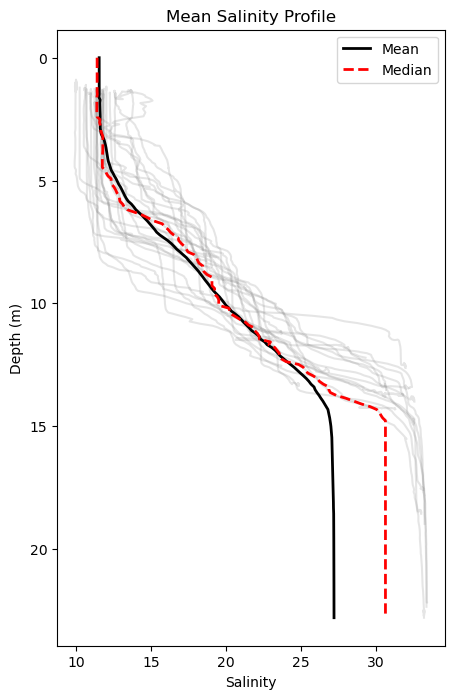

In [14]:
interp_sals = []

for p in profiles:
    depth = p['DEPTH']
    sal = p['PSAL']
    
    mask = ~np.isnan(depth) & ~np.isnan(sal)
    
    try:
        interp_sal = np.interp(common_depth, depth[mask], sal[mask])
        interp_sals.append(interp_sal)
    except:
        continue

interp_sals = np.array(interp_sals)
mean_sal = np.nanmean(interp_sals, axis=0)
median_sal = np.nanmedian(interp_sals, axis=0)  # optional (often better)

plt.figure(figsize=(5, 8))

# All profiles
for p in profiles:
    plt.plot(p['PSAL'], p['DEPTH'], color='gray', alpha=0.2)

# Mean profile
plt.plot(mean_sal, common_depth, color='black', linewidth=2, label='Mean')

# Median profile (optional but nice)
plt.plot(median_sal, common_depth, color='red', linewidth=2, linestyle='--', label='Median')

plt.gca().invert_yaxis()
plt.xlabel("Salinity")
plt.ylabel("Depth (m)")
plt.title("Mean Salinity Profile")
plt.legend()

plt.show()

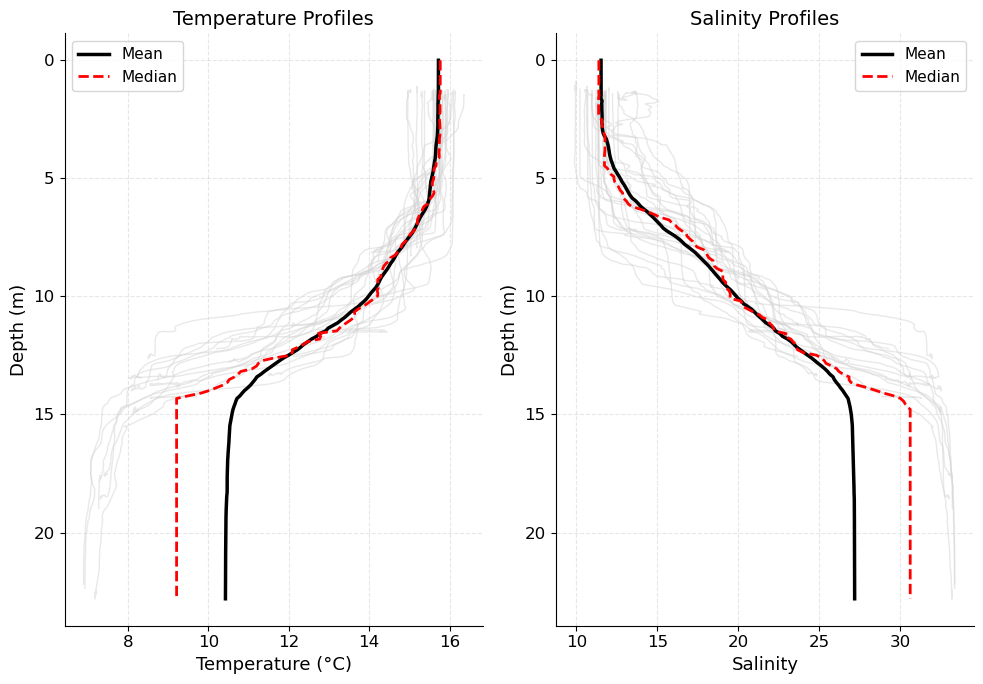

In [17]:

# ---- SET STYLE ----
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})

# ---- CREATE FIGURE ----
fig, ax = plt.subplots(1, 2, figsize=(10, 7))

# ---- PLOT ALL PROFILES (light grey) ----
for p in profiles:
    ax[0].plot(p['tv290C'], p['DEPTH'], color='lightgrey', linewidth=1, alpha=0.5)
    ax[1].plot(p['PSAL'], p['DEPTH'], color='lightgrey', linewidth=1, alpha=0.5)

# ---- PLOT MEAN + MEDIAN ----
ax[0].plot(mean_temp, common_depth, color='black', linewidth=2.5, label='Mean')
ax[0].plot(median_temp, common_depth, color='red', linewidth=2, linestyle='--', label='Median')

ax[1].plot(mean_sal, common_depth, color='black', linewidth=2.5, label='Mean')
ax[1].plot(median_sal, common_depth, color='red', linewidth=2, linestyle='--', label='Median')

# ---- FORMAT ----
for a in ax:
    a.invert_yaxis()

ax[0].set_xlabel("Temperature (°C)")
ax[0].set_ylabel("Depth (m)")

ax[1].set_xlabel("Salinity")
ax[1].set_ylabel("Depth (m)")

ax[0].set_title("Temperature Profiles")
ax[1].set_title("Salinity Profiles")

# nicer grid
for a in ax:
    a.grid(True, linestyle='--', alpha=0.3)

# legend
for a in ax:
    a.legend()

# remove top/right spines (clean look)
for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

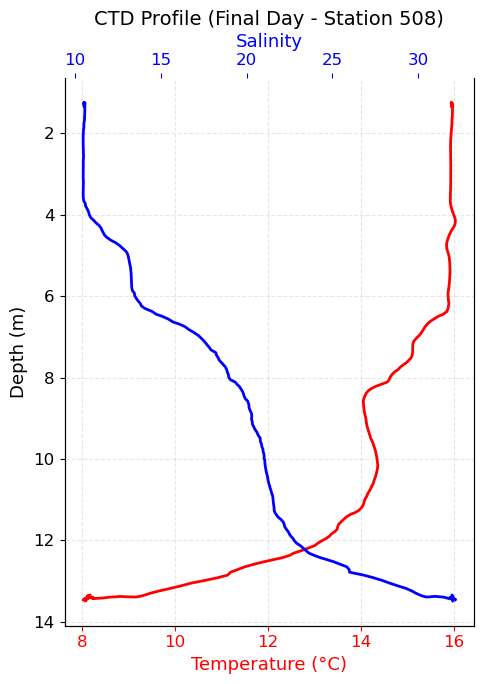

In [24]:
import os
from seabird.cnv import fCNV
import matplotlib.pyplot as plt

folder = "/Users/ej/Desktop/Applied Ocean Observation Technologies/SEABIRD/Processed"

# get file for cast 508 (final day)
file_508 = [f for f in os.listdir(folder) if "508" in f][0]
p = fCNV(os.path.join(folder, file_508))

# ---- CREATE PLOT ----
fig, ax1 = plt.subplots(figsize=(5, 7))

# Temperature (left axis)
ax1.plot(p['tv290C'], p['DEPTH'], color='red', linewidth=2, label='Temperature')
ax1.set_xlabel("Temperature (°C)", color='red')
ax1.tick_params(axis='x', colors='red')

# Depth formatting
ax1.set_ylabel("Depth (m)")
ax1.invert_yaxis()

# Salinity (right axis)
ax2 = ax1.twiny()
ax2.plot(p['PSAL'], p['DEPTH'], color='blue', linewidth=2, label='Salinity')
ax2.set_xlabel("Salinity", color='blue')
ax2.tick_params(axis='x', colors='blue')

# ---- CLEAN STYLE ----
ax1.grid(True, linestyle='--', alpha=0.3)

ax1.set_title("CTD Profile (Final Day - Station 508)")

# remove top/right spines properly
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

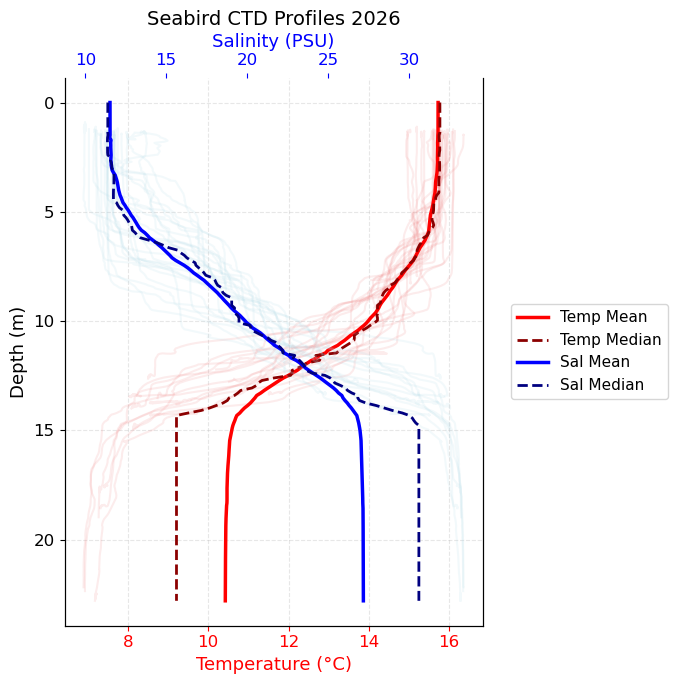

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ---- INTERPOLATION GRID ----
max_depth = max([np.nanmax(p['DEPTH']) for p in profiles])
common_depth = np.linspace(0, max_depth, 200)

interp_temps = []
interp_sals = []

# ---- INTERPOLATE ALL PROFILES ----
for p in profiles:
    depth = p['DEPTH']
    temp = p['tv290C']
    sal = p['PSAL']
    
    mask_t = ~np.isnan(depth) & ~np.isnan(temp)
    mask_s = ~np.isnan(depth) & ~np.isnan(sal)

    try:
        interp_temps.append(np.interp(common_depth, depth[mask_t], temp[mask_t]))
        interp_sals.append(np.interp(common_depth, depth[mask_s], sal[mask_s]))
    except:
        continue

interp_temps = np.array(interp_temps)
interp_sals = np.array(interp_sals)

# ---- MEAN + MEDIAN ----
mean_temp = np.nanmean(interp_temps, axis=0)
median_temp = np.nanmedian(interp_temps, axis=0)

mean_sal = np.nanmean(interp_sals, axis=0)
median_sal = np.nanmedian(interp_sals, axis=0)

# ---- PLOT ----
fig, ax1 = plt.subplots(figsize=(7, 7))

# ALL temperature profiles
for p in profiles:
    ax1.plot(p['tv290C'], p['DEPTH'], color='lightcoral', alpha=0.15)

# MEAN + MEDIAN temperature
ax1.plot(mean_temp, common_depth, color='red', linewidth=2.5, label='Temp Mean')
ax1.plot(median_temp, common_depth, color='darkred', linestyle='--', linewidth=2, label='Temp Median')

ax1.set_xlabel("Temperature (°C)", color='red')
ax1.tick_params(axis='x', colors='red')

# DEPTH
ax1.set_ylabel("Depth (m)")
ax1.invert_yaxis()

# ---- SALINITY (second axis) ----
ax2 = ax1.twiny()

# ALL salinity profiles
for p in profiles:
    ax2.plot(p['PSAL'], p['DEPTH'], color='lightblue', alpha=0.15)

# MEAN + MEDIAN salinity
ax2.plot(mean_sal, common_depth, color='blue', linewidth=2.5, label='Sal Mean')
ax2.plot(median_sal, common_depth, color='navy', linestyle='--', linewidth=2, label='Sal Median')

ax2.set_xlabel("Salinity (PSU)", color='blue')
ax2.tick_params(axis='x', colors='blue')

# ---- STYLE ----
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.set_title("Seabird CTD Profiles 2026")

# remove top borders
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# ---- COMBINED LEGEND ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.tight_layout()
plt.show()

In [35]:
import pandas as pd
import os

folder_2025 = "/Users/ej/Desktop/Applied Ocean Observation Technologies/Seabird 2025/Friday"

file_csv = [f for f in os.listdir(folder_2025) if f.endswith(".csv")][0]

df_2025 = pd.read_csv(os.path.join(folder_2025, file_csv))

print(df_2025.columns)

NumExpr defaulting to 8 threads.


Index(['Flag', 'Temperature [ITS-90 deg C]', 'Pressure [Strain Gauge db]',
       'Conductivity [S/m]', 'Oxygen [Derived mL/L]', 'Oxygen-Raw-43 [Raw V]',
       'Time [Elapsed seconds]'],
      dtype='object')


In [36]:
!pip install gsw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 7.4 MB/s  0:00:00m eta 0:00:01


In [46]:
import numpy as np

# extract raw
temp_2025 = df_2025['Temperature [ITS-90 deg C]'].values
pressure_2025 = df_2025['Pressure [Strain Gauge db]'].values
conductivity_2025 = df_2025['Conductivity [S/m]'].values
oxygen_2025 = df_2025['Oxygen [Derived mL/L]'].values

# extract raw arrays
temp_2025 = df_2025['Temperature [ITS-90 deg C]'].values
pressure_2025 = df_2025['Pressure [Strain Gauge db]'].values
conductivity_2025 = df_2025['Conductivity [S/m]'].values
oxygen_2025 = df_2025['Oxygen [Derived mL/L]'].values

# ---- ONE SINGLE MASK FOR ALL VARIABLES ----
mask = (
    (~np.isnan(temp_2025)) &
    (~np.isnan(pressure_2025)) &
    (~np.isnan(conductivity_2025)) &
    (~np.isnan(oxygen_2025)) &
    (pressure_2025 > 0) & (pressure_2025 < 100)
)

# apply mask ONCE to everything
temp_2025 = temp_2025[mask]
pressure_2025 = pressure_2025[mask]
conductivity_2025 = conductivity_2025[mask]
oxygen_2025 = oxygen_2025[mask]

# ---- SORT BY DEPTH ----
sort_idx = np.argsort(pressure_2025)

temp_2025 = temp_2025[sort_idx]
pressure_2025 = pressure_2025[sort_idx]
conductivity_2025 = conductivity_2025[sort_idx]
oxygen_2025 = oxygen_2025[sort_idx]

In [47]:
import gsw

conductivity_ms_cm = conductivity_2025 * 10

salinity_2025 = gsw.SP_from_C(
    conductivity_ms_cm,
    temp_2025,
    pressure_2025
)

In [48]:
oxygen_2025 = df_2025['Oxygen [Derived mL/L]'].values

ValueError: x and y must have same first dimension, but have shapes (32655,) and (32652,)

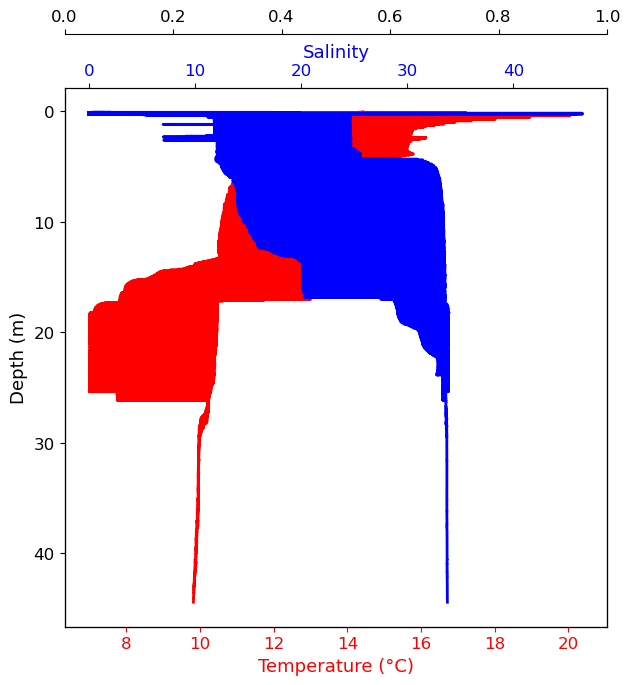

In [49]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(7, 7))

# ---- TEMPERATURE ----
ax1.plot(temp_2025, pressure_2025,
         color='red', linewidth=2, label='Temp (2025)')

ax1.set_xlabel("Temperature (°C)", color='red')
ax1.tick_params(axis='x', colors='red')

# ---- DEPTH ----
ax1.set_ylabel("Depth (m)")
ax1.invert_yaxis()

# ---- SALINITY ----
ax2 = ax1.twiny()
ax2.plot(salinity_2025, pressure_2025,
         color='blue', linewidth=2, label='Salinity (2025)')

ax2.set_xlabel("Salinity", color='blue')
ax2.tick_params(axis='x', colors='blue')

# ---- OXYGEN (third axis slightly shifted) ----
ax3 = ax1.twiny()
ax3.spines["top"].set_position(("axes", 1.1))  # move it above salinity

ax3.plot(oxygen_2025, pressure_2025,
         color='green', linewidth=2, label='Oxygen (2025)')

ax3.set_xlabel("Oxygen (mL/L)", color='green')
ax3.tick_params(axis='x', colors='green')

# ---- STYLE ----
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.set_title("CTD Profile 2025 (T, S, O₂)")

# ---- LEGEND OUTSIDE ----
lines = (
    ax1.get_lines() +
    ax2.get_lines() +
    ax3.get_lines()
)

labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

plt.tight_layout(rect=[0, 0, 0.75, 1])
plt.show()